In [1]:
import sys
from pathlib import Path
from scipy.optimize import curve_fit
from typing import Literal, Dict, Any

module_dir = Path.cwd().parent
sys.path.append(str(module_dir))

from ProxiPal import *

OS:				 Windows-11-10.0.26200-SP0
Python version:		 3.12.6 | packaged by conda-forge | (main, Sep 22 2024, 14:01:26) [MSC v.1941 64 bit (AMD64)]
Date and Time:		 2026-06-26 12:49:03
cwd:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\PPD_Cohort
base_path:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal
python_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\python
templates_folder:	 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\templates
data_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\data
samples_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\samples
quality_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\quality
user_downloads:		 C:\Users\smith.j\OneDrive

In [2]:
ppd_df = pd.read_csv("PPD Simoa vs iPLA.csv")
ppd_df

,Unnamed: 0,dx_nd_ppd,nfl_pla_li_hep,nfl_goth_li_hep,sort_the_sheet
0,1,PPD,16.000000,16.00,1.0
1,2,PPD,4.000000,4.37,2.0
2,3,PPD,8.000000,12.40,3.0
3,4,PPD,3.000000,3.39,4.0
4,5,PPD,5.000000,5.65,5.0
...,...,...,...,...,...
170,173,Dementia,15.313921,14.20,306.0
171,174,Dementia,21.463206,24.00,307.0
172,175,Dementia,8.053862,9.38,308.0
173,176,Dementia,10.761362,9.35,309.0


### Cohort NfL Concentrations

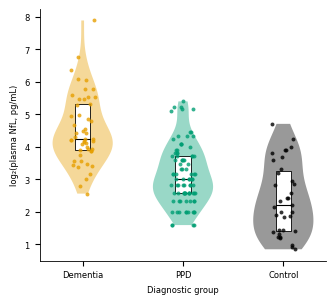

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rng = np.random.default_rng(0)             # seeded for reproducible jitter

VALUE_COL = "nfl_pla_li_hep"
GROUP_COL = "dx_nd_ppd"
LOG_COL = "log2_nfl"

colors = {
    "Control": "#000000",
    "PPD": "#009E73",
    "Dementia": "#E69F00",
}
group_order = ["Dementia", "PPD", "Control"]

# log2-transform the data itself (NOT an axis-scale transform) — matches the
# 0.5/1.0/1.5/2.0 evenly-spaced tick pattern you're trying to reproduce
ppd_df[LOG_COL] = np.log2(ppd_df[VALUE_COL])

fig, ax = plt.subplots(figsize=(88/25.4, 80/25.4))  # 88mm single-col

groups = [g for g in group_order if g in ppd_df[GROUP_COL].unique()]
missing = set(group_order) - set(groups)
if missing:
    print(f"Warning: groups {missing} not found in {GROUP_COL} — check category labels")

for i, grp in enumerate(groups):
    vals = ppd_df.loc[ppd_df[GROUP_COL] == grp, LOG_COL].dropna().values
    color = colors[grp]

    if len(vals) < 2 or np.std(vals) == 0:
        print(f"Warning: group '{grp}' has n={len(vals)}, std={np.std(vals) if len(vals) else 'NA'} — skipping violin body")
    else:
        parts = ax.violinplot(vals, positions=[i], widths=0.6,
                              showmedians=False, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_alpha(0.4)
            pc.set_edgecolor("none")
            pc.set_zorder(2)

    if len(vals) > 0:
        q1, median, q3 = np.percentile(vals, [25, 50, 75])
        box_width = 0.15
        ax.add_patch(plt.Rectangle((i - box_width/2, q1), box_width, q3 - q1,
                                    facecolor="white", edgecolor="black",
                                    linewidth=0.6, zorder=3))
        ax.plot([i - box_width/2, i + box_width/2], [median, median],
                color="black", linewidth=0.8, zorder=4)

    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(i + jitter, vals, color=color, s=8, alpha=0.8,
               linewidths=0, zorder=5)

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, fontsize=6, fontname="Sans")
ax.set_ylabel("log\u2082(plasma NfL, pg/mL)", fontsize=6, fontname="Sans")
ax.set_xlabel("Diagnostic group", fontsize=6, fontname="Sans")
ax.tick_params(axis="both", labelsize=6)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.6)

plt.tight_layout()
# plt.savefig("NfL_dx_violin_log2.svg", dpi=300, bbox_inches="tight")
plt.show()

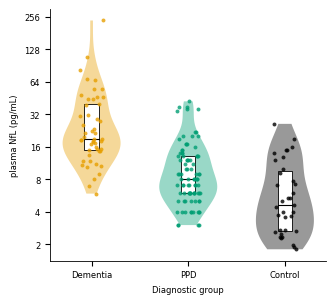

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

rng = np.random.default_rng(0)             # seeded for reproducible jitter

VALUE_COL = "nfl_pla_li_hep"
GROUP_COL = "dx_nd_ppd"
LOG_COL = "log2_nfl"

colors = {
    "Control": "#000000",
    "PPD": "#009E73",
    "Dementia": "#E69F00",
}
group_order = ["Dementia", "PPD", "Control"]

ppd_df[LOG_COL] = np.log2(ppd_df[VALUE_COL])

fig, ax = plt.subplots(figsize=(88/25.4, 80/25.4))  # 88mm single-col

groups = [g for g in group_order if g in ppd_df[GROUP_COL].unique()]
missing = set(group_order) - set(groups)
if missing:
    print(f"Warning: groups {missing} not found in {GROUP_COL} — check category labels")

for i, grp in enumerate(groups):
    vals = ppd_df.loc[ppd_df[GROUP_COL] == grp, LOG_COL].dropna().values
    color = colors[grp]

    if len(vals) < 2 or np.std(vals) == 0:
        print(f"Warning: group '{grp}' has n={len(vals)}, std={np.std(vals) if len(vals) else 'NA'} — skipping violin body")
    else:
        parts = ax.violinplot(vals, positions=[i], widths=0.6,
                              showmedians=False, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_alpha(0.4)
            pc.set_edgecolor("none")
            pc.set_zorder(2)

    if len(vals) > 0:
        q1, median, q3 = np.percentile(vals, [25, 50, 75])
        box_width = 0.15
        ax.add_patch(plt.Rectangle((i - box_width/2, q1), box_width, q3 - q1,
                                    facecolor="white", edgecolor="black",
                                    linewidth=0.6, zorder=3))
        ax.plot([i - box_width/2, i + box_width/2], [median, median],
                color="black", linewidth=0.8, zorder=4)

    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(i + jitter, vals, color=color, s=8, alpha=0.8,
               linewidths=0, zorder=5)

# tick positions stay in log2 space; label is back-transformed and rounded to nearest integer
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{2**y:.0f}"))

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, fontsize=6, fontname="Sans")
ax.set_ylabel("plasma NfL (pg/mL)", fontsize=6, fontname="Sans")
ax.set_xlabel("Diagnostic group", fontsize=6, fontname="Sans")
ax.tick_params(axis="both", labelsize=6)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.6)

plt.tight_layout()
plt.savefig("NfL_dx_violin_log2_intlabels.svg", dpi=300, bbox_inches="tight")
plt.show()

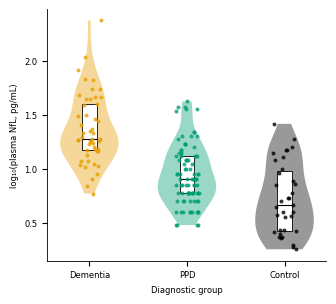

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rng = np.random.default_rng(0)             # seeded for reproducible jitter

VALUE_COL = "nfl_pla_li_hep"
GROUP_COL = "dx_nd_ppd"
LOG_COL = "log10_nfl"

colors = {
    "Control": "#000000",
    "PPD": "#009E73",
    "Dementia": "#E69F00",
}
group_order = ["Dementia", "PPD", "Control"]

# log10-transform the data itself (NOT an axis-scale transform)
ppd_df[LOG_COL] = np.log10(ppd_df[VALUE_COL])

fig, ax = plt.subplots(figsize=(88/25.4, 80/25.4))  # 88mm single-col

groups = [g for g in group_order if g in ppd_df[GROUP_COL].unique()]
missing = set(group_order) - set(groups)
if missing:
    print(f"Warning: groups {missing} not found in {GROUP_COL} — check category labels")

for i, grp in enumerate(groups):
    vals = ppd_df.loc[ppd_df[GROUP_COL] == grp, LOG_COL].dropna().values
    color = colors[grp]

    if len(vals) < 2 or np.std(vals) == 0:
        print(f"Warning: group '{grp}' has n={len(vals)}, std={np.std(vals) if len(vals) else 'NA'} — skipping violin body")
    else:
        parts = ax.violinplot(vals, positions=[i], widths=0.6,
                              showmedians=False, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_alpha(0.4)
            pc.set_edgecolor("none")
            pc.set_zorder(2)

    if len(vals) > 0:
        q1, median, q3 = np.percentile(vals, [25, 50, 75])
        box_width = 0.15
        ax.add_patch(plt.Rectangle((i - box_width/2, q1), box_width, q3 - q1,
                                    facecolor="white", edgecolor="black",
                                    linewidth=0.6, zorder=3))
        ax.plot([i - box_width/2, i + box_width/2], [median, median],
                color="black", linewidth=0.8, zorder=4)

    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(i + jitter, vals, color=color, s=8, alpha=0.8,
               linewidths=0, zorder=5)

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, fontsize=6, fontname="Sans")
ax.set_ylabel("log\u2081\u2080(plasma NfL, pg/mL)", fontsize=6, fontname="Sans")
ax.set_xlabel("Diagnostic group", fontsize=6, fontname="Sans")
ax.tick_params(axis="both", labelsize=6)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.6)

plt.tight_layout()
# plt.savefig("NfL_dx_violin_log10.svg", dpi=300, bbox_inches="tight")
plt.show()

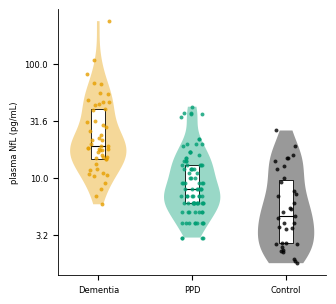

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

rng = np.random.default_rng(0)             # seeded for reproducible jitter

VALUE_COL = "nfl_pla_li_hep"
GROUP_COL = "dx_nd_ppd"
LOG_COL = "log10_nfl"

colors = {
    "Control": "#000000",
    "PPD": "#009E73",
    "Dementia": "#E69F00",
}
group_order = ["Dementia", "PPD", "Control"]

ppd_df[LOG_COL] = np.log10(ppd_df[VALUE_COL])

fig, ax = plt.subplots(figsize=(88/25.4, 80/25.4))  # 88mm single-col

groups = [g for g in group_order if g in ppd_df[GROUP_COL].unique()]
missing = set(group_order) - set(groups)
if missing:
    print(f"Warning: groups {missing} not found in {GROUP_COL} — check category labels")

for i, grp in enumerate(groups):
    vals = ppd_df.loc[ppd_df[GROUP_COL] == grp, LOG_COL].dropna().values
    color = colors[grp]

    if len(vals) < 2 or np.std(vals) == 0:
        print(f"Warning: group '{grp}' has n={len(vals)}, std={np.std(vals) if len(vals) else 'NA'} — skipping violin body")
    else:
        parts = ax.violinplot(vals, positions=[i], widths=0.6,
                              showmedians=False, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_alpha(0.4)
            pc.set_edgecolor("none")
            pc.set_zorder(2)

    if len(vals) > 0:
        q1, median, q3 = np.percentile(vals, [25, 50, 75])
        box_width = 0.15
        ax.add_patch(plt.Rectangle((i - box_width/2, q1), box_width, q3 - q1,
                                    facecolor="white", edgecolor="black",
                                    linewidth=0.6, zorder=3))
        ax.plot([i - box_width/2, i + box_width/2], [median, median],
                color="black", linewidth=0.8, zorder=4)

    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(i + jitter, vals, color=color, s=8, alpha=0.8,
               linewidths=0, zorder=5)

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{10**y:.1f}"))

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, fontsize=6, fontname="Sans")
ax.set_ylabel("plasma NfL (pg/mL)", fontsize=6, fontname="Sans")
# ax.set_xlabel("Diagnostic group", fontsize=6, fontname="Sans")
ax.tick_params(axis="both", labelsize=6)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.6)

plt.tight_layout()
# plt.savefig("NfL_dx_violin_log10_actuallabels.svg", dpi=300, bbox_inches="tight")
plt.show()

### Delong

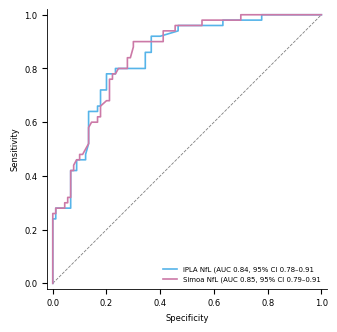

=== Per-marker AUC (DeLong, computed on each marker's own available N) ===
iPLA NfL: AUC=0.84, 95% CI [0.78, 0.91], n_pos=50, n_neg=90
Simoa NfL: AUC=0.85, 95% CI [0.79, 0.91], n_pos=50, n_neg=90

=== Paired DeLong test (iPLA vs Simoa, common subjects only, n=140) ===
AUC iPLA=0.84, AUC Simoa=0.85, z=-0.35, p=0.73


In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
from scipy import stats

# ============================================================
# DeLong's method (Sun & Xu 2014 fast midrank algorithm) —
# this is the same algorithm R's pROC package uses for method="delong",
# validated here against sklearn's roc_auc_score for exact point-estimate match.
# ============================================================
def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def fast_delong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]
    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)
    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / (2.0 * n)
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.atleast_2d(np.cov(v01))   # atleast_2d guards against np.cov collapsing
    sy = np.atleast_2d(np.cov(v10))   # to a 0-d scalar for the single-marker case
    delongcov = sx / m + sy / n
    return aucs, delongcov

def delong_auc_ci(y_true, y_score, alpha=0.95):
    """Single-marker AUC point estimate + DeLong 95% CI."""
    order = np.argsort(-y_true)
    preds_sorted = y_score[np.newaxis, order]
    label_1_count = int(np.sum(y_true))
    aucs, cov = fast_delong(preds_sorted, label_1_count)
    auc = aucs[0]
    se = np.sqrt(cov[0, 0])
    z = stats.norm.ppf(1 - (1 - alpha) / 2)
    lo, hi = auc - z * se, auc + z * se
    return auc, se, max(0.0, lo), min(1.0, hi)   # clip to valid AUC range

def delong_paired_test(y_true, score_1, score_2):
    """Paired DeLong test comparing two markers measured on the same subjects."""
    order = np.argsort(-y_true)
    preds_sorted = np.vstack([score_1, score_2])[:, order]
    label_1_count = int(np.sum(y_true))
    aucs, cov = fast_delong(preds_sorted, label_1_count)
    auc1, auc2 = aucs
    var1, var2, covar = cov[0, 0], cov[1, 1], cov[0, 1]
    se_diff = np.sqrt(var1 + var2 - 2 * covar)
    z = (auc1 - auc2) / se_diff
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return auc1, auc2, z, p

# ============================================================
# Plot 1: Dementia vs PPD — iPLA NfL and Simoa NfL overlaid
# ============================================================
GROUP_COL = "dx_nd_ppd"
POS_LABEL = "Dementia"   # positive class: higher NfL = more neurodegeneration
NEG_LABEL = "PPD"

markers = {
    "nfl_pla_li_hep": {"label": "iPLA NfL", "color": "#56B4E9"},
    "nfl_goth_li_hep": {"label": "Simoa NfL", "color": "#CC79A7"},
}

subset = ppd_df[ppd_df[GROUP_COL].isin([POS_LABEL, NEG_LABEL])].copy()

fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))  # square panel, standard for ROC

results = {}
for col, meta in markers.items():
    paired = subset[[GROUP_COL, col]].dropna()
    y_true = (paired[GROUP_COL] == POS_LABEL).astype(int).values
    y_score = paired[col].values
    n_pos_used = y_true.sum()
    n_neg_used = len(y_true) - n_pos_used

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc, se, ci_lo, ci_hi = delong_auc_ci(y_true, y_score)
    results[col] = dict(auc=auc, se=se, ci_lo=ci_lo, ci_hi=ci_hi,
                         n_pos=n_pos_used, n_neg=n_neg_used)

    ax.plot(fpr, tpr, color=meta["color"], linewidth=1.2,
             label=f"{meta['label']} (AUC {auc:.2f}, 95% CI {ci_lo:.2f}\u2013{ci_hi:.2f}")

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=0.6, zorder=1)

ax.set_xlabel("Specificity", fontsize=6, fontname="Sans")
ax.set_ylabel("Sensitivity", fontsize=6, fontname="Sans")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.tick_params(axis="both", labelsize=6)
ax.legend(fontsize=5, loc="lower right", frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.6)

plt.tight_layout()
plt.savefig("ROC_dementia_vs_ppd.svg", dpi=300, bbox_inches="tight")
plt.show()

# --- paired DeLong test: iPLA vs Simoa, restricted to subjects with BOTH values ---
common = subset[[GROUP_COL, "nfl_pla_li_hep", "nfl_goth_li_hep"]].dropna()
y_true_common = (common[GROUP_COL] == POS_LABEL).astype(int).values
auc1, auc2, z, p = delong_paired_test(y_true_common,
                                        common["nfl_pla_li_hep"].values,
                                        common["nfl_goth_li_hep"].values)

print("=== Per-marker AUC (DeLong, computed on each marker's own available N) ===")
for col, meta in markers.items():
    r = results[col]
    print(f"{meta['label']}: AUC={r['auc']:.2f}, 95% CI [{r['ci_lo']:.2f}, {r['ci_hi']:.2f}], "
          f"n_pos={r['n_pos']}, n_neg={r['n_neg']}")

print()
print(f"=== Paired DeLong test (iPLA vs Simoa, common subjects only, n={len(common)}) ===")
print(f"AUC iPLA={auc1:.2f}, AUC Simoa={auc2:.2f}, z={z:.2f}, p={p:.2f}")

### Youden

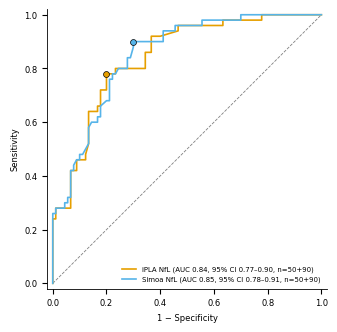

=== Per-marker AUC (bootstrap 95% CI) and Youden cutoffs ===
iPLA NfL: AUC=0.844, 95% CI [0.772, 0.902], n_pos=50, n_neg=90
  Youden cutoff: 14.67, sensitivity=0.780, specificity=0.800, J=0.580
Simoa NfL: AUC=0.850, 95% CI [0.783, 0.907], n_pos=50, n_neg=90
  Youden cutoff: 12.20, sensitivity=0.900, specificity=0.700, J=0.600

=== Bootstrapped AUC difference (iPLA − Simoa), n=2000 valid resamples of n=140 paired subjects ===
AUC iPLA=0.844, AUC Simoa=0.850
Difference=-0.007, SE=0.020, 95% CI [-0.046, 0.033], p=0.7361


In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score
from scipy import stats

# ============================================================
# Bootstrap AUC + bootstrap AUC-difference test, matching the
# collaborator's stated method ("Bootstrapped differences in AUC
# were used to compare ROC curves") rather than DeLong's analytic method.
# Resampling is at the SUBJECT level (paired), preserving the correlation
# between iPLA and Simoa measured on the same individuals.
# ============================================================

def bootstrap_auc_diff(y_true, score_1, score_2, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    idx = np.arange(n)
    diffs, aucs1, aucs2 = [], [], []
    attempts = 0
    while len(diffs) < n_boot and attempts < n_boot * 20:
        attempts += 1
        sample = rng.choice(idx, size=n, replace=True)
        yt = y_true[sample]
        if yt.sum() == 0 or yt.sum() == n:
            continue  # skip resamples missing one class entirely
        a1 = roc_auc_score(yt, score_1[sample])
        a2 = roc_auc_score(yt, score_2[sample])
        aucs1.append(a1); aucs2.append(a2); diffs.append(a1 - a2)
    diffs = np.array(diffs)
    obs_auc1 = roc_auc_score(y_true, score_1)
    obs_auc2 = roc_auc_score(y_true, score_2)
    obs_diff = obs_auc1 - obs_auc2
    se_diff = np.std(diffs, ddof=1)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    z = obs_diff / se_diff
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return dict(auc1=obs_auc1, auc2=obs_auc2, diff=obs_diff, se_diff=se_diff,
                ci_lo=ci_lo, ci_hi=ci_hi, p=p, n_boot_used=len(diffs))

def bootstrap_auc_ci(y_true, y_score, n_boot=2000, seed=0):
    """Single-marker AUC point estimate + bootstrap 95% percentile CI."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    idx = np.arange(n)
    aucs = []
    attempts = 0
    while len(aucs) < n_boot and attempts < n_boot * 20:
        attempts += 1
        sample = rng.choice(idx, size=n, replace=True)
        yt = y_true[sample]
        if yt.sum() == 0 or yt.sum() == n:
            continue
        aucs.append(roc_auc_score(yt, y_score[sample]))
    aucs = np.array(aucs)
    ci_lo, ci_hi = np.percentile(aucs, [2.5, 97.5])
    return ci_lo, ci_hi

def youden_cutoff(y_true, y_score):
    """Optimal threshold maximizing J = sensitivity + specificity - 1."""
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    J = tpr - fpr
    best = np.argmax(J)
    return dict(threshold=thresholds[best], sens=tpr[best], spec=1 - fpr[best],
                J=J[best], fpr_point=fpr[best], tpr_point=tpr[best])

# ============================================================
# Plot 1: Dementia vs PPD — iPLA NfL and Simoa NfL overlaid
# ============================================================
GROUP_COL = "dx_nd_ppd"
POS_LABEL = "Dementia"
NEG_LABEL = "PPD"

markers = {
    "nfl_pla_li_hep": {"label": "iPLA NfL", "color": "#E69F00"},
    "nfl_goth_li_hep": {"label": "Simoa NfL", "color": "#56B4E9"},
}

subset = ppd_df[ppd_df[GROUP_COL].isin([POS_LABEL, NEG_LABEL])].copy()
fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))

results = {}
for col, meta in markers.items():
    paired = subset[[GROUP_COL, col]].dropna()
    y_true = (paired[GROUP_COL] == POS_LABEL).astype(int).values
    y_score = paired[col].values
    n_pos, n_neg = y_true.sum(), len(y_true) - y_true.sum()

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    ci_lo, ci_hi = bootstrap_auc_ci(y_true, y_score, n_boot=2000, seed=0)
    yj = youden_cutoff(y_true, y_score)
    results[col] = dict(auc=auc, ci_lo=ci_lo, ci_hi=ci_hi, n_pos=n_pos, n_neg=n_neg, youden=yj)

    ax.plot(fpr, tpr, color=meta["color"], linewidth=1.2,
             label=f"{meta['label']} (AUC {auc:.2f}, 95% CI {ci_lo:.2f}\u2013{ci_hi:.2f}, n={n_pos}+{n_neg})")
    # mark the Youden-optimal operating point on each curve
    ax.scatter([yj["fpr_point"]], [yj["tpr_point"]], color=meta["color"],
               edgecolor="black", linewidth=0.5, s=18, zorder=6)

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=0.6, zorder=1)
ax.set_xlabel("1 \u2212 Specificity", fontsize=6, fontname="Sans")
ax.set_ylabel("Sensitivity", fontsize=6, fontname="Sans")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.tick_params(axis="both", labelsize=6)
ax.legend(fontsize=5, loc="lower right", frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.6)

plt.tight_layout()
# plt.savefig("ROC_dementia_vs_ppd_bootstrap.svg", dpi=300, bbox_inches="tight")
plt.show()

# --- bootstrapped AUC difference: iPLA vs Simoa, restricted to subjects with BOTH values ---
common = subset[[GROUP_COL, "nfl_pla_li_hep", "nfl_goth_li_hep"]].dropna()
y_true_common = (common[GROUP_COL] == POS_LABEL).astype(int).values
boot_result = bootstrap_auc_diff(y_true_common,
                                   common["nfl_pla_li_hep"].values,
                                   common["nfl_goth_li_hep"].values,
                                   n_boot=2000, seed=0)

print("=== Per-marker AUC (bootstrap 95% CI) and Youden cutoffs ===")
for col, meta in markers.items():
    r = results[col]
    yj = r["youden"]
    print(f"{meta['label']}: AUC={r['auc']:.3f}, 95% CI [{r['ci_lo']:.3f}, {r['ci_hi']:.3f}], "
          f"n_pos={r['n_pos']}, n_neg={r['n_neg']}")
    print(f"  Youden cutoff: {yj['threshold']:.2f}, sensitivity={yj['sens']:.3f}, "
          f"specificity={yj['spec']:.3f}, J={yj['J']:.3f}")

print()
print(f"=== Bootstrapped AUC difference (iPLA \u2212 Simoa), n={boot_result['n_boot_used']} "
      f"valid resamples of n={len(common)} paired subjects ===")
print(f"AUC iPLA={boot_result['auc1']:.3f}, AUC Simoa={boot_result['auc2']:.3f}")
print(f"Difference={boot_result['diff']:.3f}, SE={boot_result['se_diff']:.3f}, "
      f"95% CI [{boot_result['ci_lo']:.3f}, {boot_result['ci_hi']:.3f}], p={boot_result['p']:.4f}")

### Delong

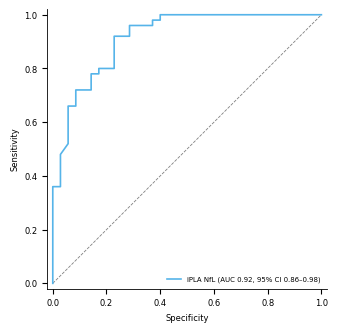

iPLA NfL: AUC=0.92, 95% CI [0.86, 0.98], n_pos=50, n_neg=35


In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
from scipy import stats

# ============================================================
# DeLong's method (Sun & Xu 2014 fast midrank algorithm)
# ============================================================
def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def fast_delong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]
    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)
    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / (2.0 * n)
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.atleast_2d(np.cov(v01))
    sy = np.atleast_2d(np.cov(v10))
    delongcov = sx / m + sy / n
    return aucs, delongcov

def delong_auc_ci(y_true, y_score, alpha=0.95):
    """Single-marker AUC point estimate + DeLong 95% CI."""
    order = np.argsort(-y_true)
    preds_sorted = y_score[np.newaxis, order]
    label_1_count = int(np.sum(y_true))
    aucs, cov = fast_delong(preds_sorted, label_1_count)
    auc = aucs[0]
    se = np.sqrt(cov[0, 0])
    z = stats.norm.ppf(1 - (1 - alpha) / 2)
    lo, hi = auc - z * se, auc + z * se
    return auc, se, max(0.0, lo), min(1.0, hi)

# ============================================================
# Plot 2: Dementia vs Control — iPLA NfL only
# ============================================================
GROUP_COL = "dx_nd_ppd"
POS_LABEL = "Dementia"
NEG_LABEL = "Control"
MARKER_COL = "nfl_pla_li_hep"
MARKER_LABEL = "iPLA NfL"
MARKER_COLOR = "#56B4E9"

subset = ppd_df[ppd_df[GROUP_COL].isin([POS_LABEL, NEG_LABEL])].copy()
paired = subset[[GROUP_COL, MARKER_COL]].dropna()
y_true = (paired[GROUP_COL] == POS_LABEL).astype(int).values
y_score = paired[MARKER_COL].values
n_pos, n_neg = y_true.sum(), len(y_true) - y_true.sum()

fpr, tpr, _ = roc_curve(y_true, y_score)
auc, se, ci_lo, ci_hi = delong_auc_ci(y_true, y_score)

fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))  # square panel, standard for ROC

ax.plot(fpr, tpr, color=MARKER_COLOR, linewidth=1.2,
         label=f"{MARKER_LABEL} (AUC {auc:.2f}, 95% CI {ci_lo:.2f}\u2013{ci_hi:.2f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=0.6, zorder=1)

ax.set_xlabel("Specificity", fontsize=6, fontname="Sans")
ax.set_ylabel("Sensitivity", fontsize=6, fontname="Sans")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.tick_params(axis="both", labelsize=6)
ax.legend(fontsize=5, loc="lower right", frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.6)

plt.tight_layout()
plt.savefig("ROC_dementia_vs_control.svg", dpi=300, bbox_inches="tight")
plt.show()

print(f"{MARKER_LABEL}: AUC={auc:.2f}, 95% CI [{ci_lo:.2f}, {ci_hi:.2f}], n_pos={n_pos}, n_neg={n_neg}")

### Youden

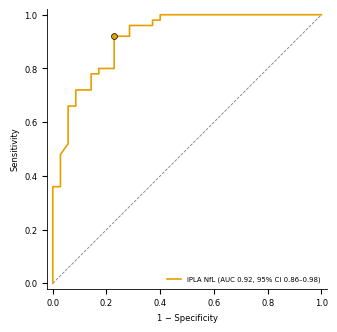

iPLA NfL: AUC=0.92, 95% CI [0.86, 0.98], n_pos=50, n_neg=35
Youden cutoff: 10.47, sensitivity=0.920, specificity=0.771, J=0.691


In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
from scipy import stats

# ============================================================
# DeLong's method (Sun & Xu 2014 fast midrank algorithm)
# ============================================================
def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def fast_delong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]
    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)
    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / (2.0 * n)
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.atleast_2d(np.cov(v01))
    sy = np.atleast_2d(np.cov(v10))
    delongcov = sx / m + sy / n
    return aucs, delongcov

def delong_auc_ci(y_true, y_score, alpha=0.95):
    """Single-marker AUC point estimate + DeLong 95% CI."""
    order = np.argsort(-y_true)
    preds_sorted = y_score[np.newaxis, order]
    label_1_count = int(np.sum(y_true))
    aucs, cov = fast_delong(preds_sorted, label_1_count)
    auc = aucs[0]
    se = np.sqrt(cov[0, 0])
    z = stats.norm.ppf(1 - (1 - alpha) / 2)
    lo, hi = auc - z * se, auc + z * se
    return auc, se, max(0.0, lo), min(1.0, hi)

def youden_cutoff(y_true, y_score):
    """Optimal threshold maximizing J = sensitivity + specificity - 1."""
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    J = tpr - fpr
    best = np.argmax(J)
    return dict(threshold=thresholds[best], sens=tpr[best], spec=1 - fpr[best],
                J=J[best], fpr_point=fpr[best], tpr_point=tpr[best])

# ============================================================
# Plot 2: Dementia vs Control — iPLA NfL only, with Youden cutoff marked
# ============================================================
GROUP_COL = "dx_nd_ppd"
POS_LABEL = "Dementia"
NEG_LABEL = "Control"
MARKER_COL = "nfl_pla_li_hep"
MARKER_LABEL = "iPLA NfL"
MARKER_COLOR = "#E69F00"

subset = ppd_df[ppd_df[GROUP_COL].isin([POS_LABEL, NEG_LABEL])].copy()
paired = subset[[GROUP_COL, MARKER_COL]].dropna()
y_true = (paired[GROUP_COL] == POS_LABEL).astype(int).values
y_score = paired[MARKER_COL].values
n_pos, n_neg = y_true.sum(), len(y_true) - y_true.sum()

fpr, tpr, _ = roc_curve(y_true, y_score)
auc, se, ci_lo, ci_hi = delong_auc_ci(y_true, y_score)
yj = youden_cutoff(y_true, y_score)

fig, ax = plt.subplots(figsize=(88/25.4, 88/25.4))  # square panel, standard for ROC

ax.plot(fpr, tpr, color=MARKER_COLOR, linewidth=1.2,
         label=f"{MARKER_LABEL} (AUC {auc:.2f}, 95% CI {ci_lo:.2f}\u2013{ci_hi:.2f})")

# mark the Youden-optimal operating point
ax.scatter([yj["fpr_point"]], [yj["tpr_point"]], color=MARKER_COLOR,
           edgecolor="black", linewidth=0.5, s=18, zorder=6)

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=0.6, zorder=1)

ax.set_xlabel("1 \u2212 Specificity", fontsize=6, fontname="Sans")
ax.set_ylabel("Sensitivity", fontsize=6, fontname="Sans")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.tick_params(axis="both", labelsize=6)
ax.legend(fontsize=5, loc="lower right", frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.6)

plt.tight_layout()
# plt.savefig("ROC_dementia_vs_control.svg", dpi=300, bbox_inches="tight")
plt.show()

print(f"{MARKER_LABEL}: AUC={auc:.2f}, 95% CI [{ci_lo:.2f}, {ci_hi:.2f}], n_pos={n_pos}, n_neg={n_neg}")
print(f"Youden cutoff: {yj['threshold']:.2f}, sensitivity={yj['sens']:.3f}, "
      f"specificity={yj['spec']:.3f}, J={yj['J']:.3f}")